# 18 - Structural paradigm shift: phlogiston as a Gaussian Bayes net

Each agent's paradigm is a **Gaussian belief in information form** $(\Pi, h)$ over a vector of
theoretical commitments $\phi$: $\;p(\phi)\propto\exp(-\tfrac12\phi^\top\Pi\phi + h^\top\phi)$.
The precision matrix $\Pi$ *is* the paradigm net written as numbers (diagonal = self-precision,
off-diagonal = inferential coupling = an edge). Three moves on the one object
(`notes/bmr_feynman_linear_algebra.tex`):

- **learn** = add Fisher information ($\Pi\mathrel{+}=J$),
- **expand** = border the matrix (a new commitment),
- **reduce** = Schur-complement (marginalize, the *carry-over*) or prune (BMR, the *evidence bill*).

> *A belief is an information matrix. To learn is to add to it. To restructure is to border it or
> Schur-complement it. To price the restructuring is to evaluate a moment generating function.*

This notebook runs the phlogiston-vs-oxygen experiment: ten commitments, two candidate prior
topologies, a world whose revealed mass behaviour flips (crude vs gravimetric), and agents that
communicate by transmitting their **entire** belief net and fusing by precision addition.


In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / 'src').exists() else ROOT.parent))

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import jax

from src import structural as st
from src.structural import phlogiston as ph
from src.structural import observables as obs
from src.structural import step as S
from src.history import History
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
print('imports OK')


imports OK


## 1. The two candidate paradigms

`phlogiston` (node 0) is the dense hub on which the combustion/calcination/mass commitments depend
-- the hidden principle that makes the surface phenomena co-vary. `oxygen` has no hub: the Lavoisian
direct mass law couples mass-change, gas-consumption and calx-weight directly. The oxygen net is
built as the **Schur complement of the phlogiston net over the hub** (inheriting the carry-over
edges) plus a small gravimetric prior.


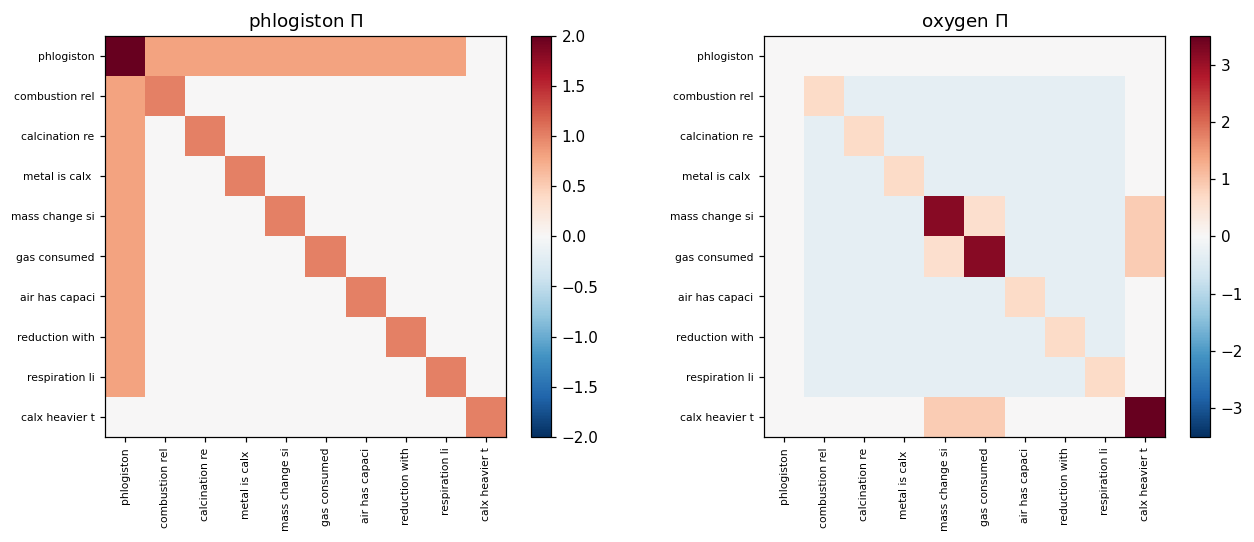

phlogiston is a hub (row 0 dense); oxygen has no hub but a mass-law block among nodes 4,5,9


In [2]:
cfg = ph.StructuralConfig()
phlog = ph.phlogiston_prior(cfg)
oxy   = ph.oxygen_prior(cfg)
names = cfg.node_names
short = [n.replace('_', ' ')[:14] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, net, title in [(axes[0], phlog, 'phlogiston $\\Pi$'), (axes[1], oxy, 'oxygen $\\Pi$')]:
    M = np.asarray(net.Pi)
    im = ax.imshow(M, cmap='RdBu_r', vmin=-np.abs(M).max(), vmax=np.abs(M).max())
    ax.set_title(title); ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names)))
    ax.set_xticklabels(short, rotation=90, fontsize=7); ax.set_yticklabels(short, fontsize=7)
    ax.grid(False); fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()
print('phlogiston is a hub (row 0 dense); oxygen has no hub but a mass-law block among nodes 4,5,9')


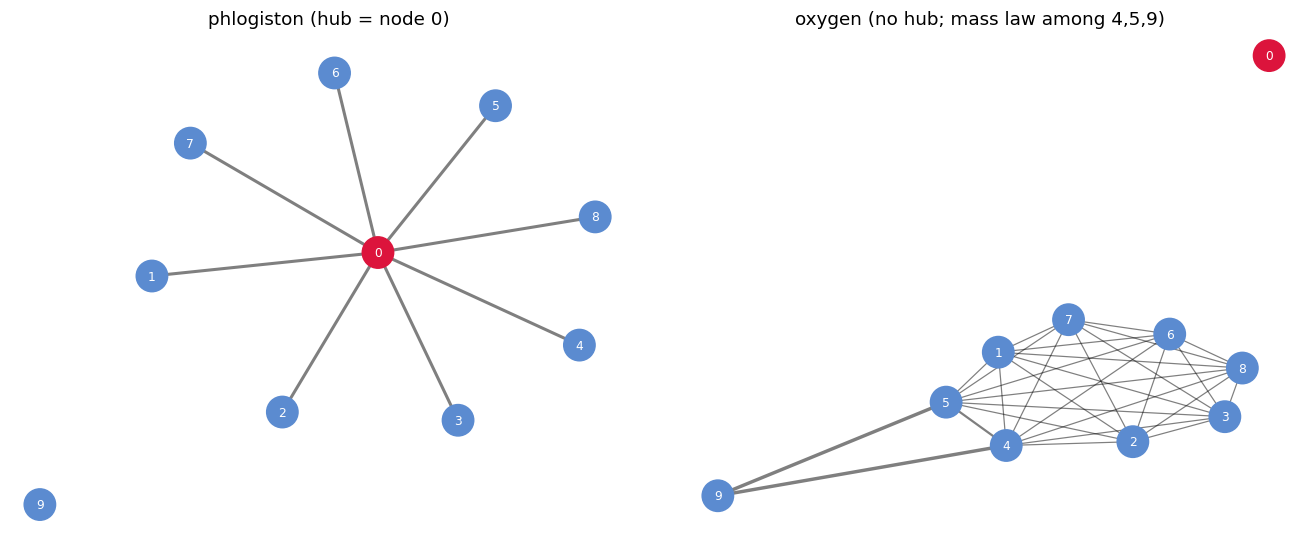

In [3]:
# the same two beliefs as graphs
def draw_net(ax, net, title, hub=None):
    M = np.asarray(net.Pi); d = M.shape[0]
    G = nx.Graph()
    G.add_nodes_from(range(d))
    for i in range(d):
        for j in range(i+1, d):
            if abs(M[i, j]) > 1e-6:
                G.add_edge(i, j, w=abs(M[i, j]))
    pos = nx.spring_layout(G, seed=1, k=0.9)
    cols = ['crimson' if (hub and net.names[i] == ph.HUB) else '#5b8bd0' for i in range(d)]
    ws = [2.5*G[u][v]['w'] for u, v in G.edges()]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=cols, node_size=420)
    nx.draw_networkx_edges(G, pos, ax=ax, width=ws, alpha=0.5)
    nx.draw_networkx_labels(G, pos, ax=ax, labels={i: i for i in range(d)}, font_size=8, font_color='white')
    ax.set_title(title); ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
draw_net(axes[0], phlog, 'phlogiston (hub = node 0)', hub=True)
draw_net(axes[1], oxy, 'oxygen (no hub; mass law among 4,5,9)', hub=True)
plt.tight_layout(); plt.show()


## 2. The carry-over: marginalizing the phlogiston hub *writes* the mass law

Removing the hub by Schur complement is not free: it deposits fill-in edges among the hub's former
neighbours. That fill-in **is** the Lavoisian direct mass law (the paper's Appendix $A\to B$ step).
The Frobenius mass of the fill-in is the literal *importance* of a node.


survivor basis: ('combustion_releases', 'calcination_releases', 'metal_is_calx_plus_phlog', 'mass_change_sign', 'gas_consumed', 'air_has_capacity', 'reduction_with_charcoal', 'respiration_like_combustion', 'calx_heavier_than_metal')
carryover_mass(phlogiston hub) = 2.560
carryover_mass(belt node calx_heavier) = 0.000


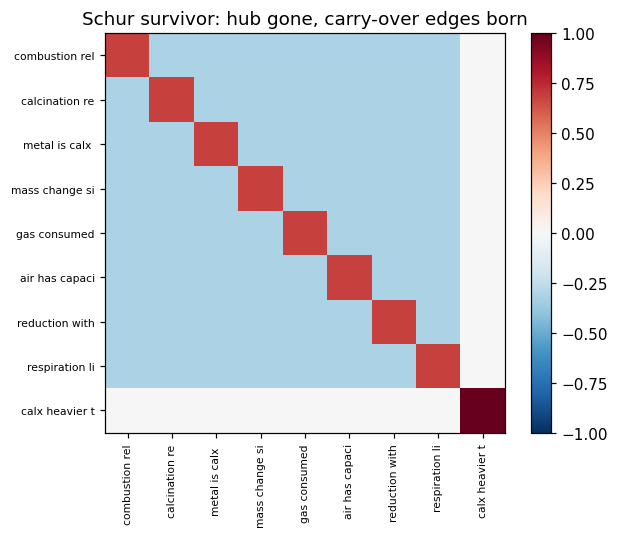

A hub leaves a dense ghost; a belt node leaves none. Importance = fill-in.


In [4]:
surv = st.schur_marginalize(phlog, (ph.HUB,))
print('survivor basis:', surv.names)
print('carryover_mass(phlogiston hub) = %.3f' % obs.carryover_mass(phlog, (ph.HUB,)))
print('carryover_mass(belt node calx_heavier) = %.3f' % obs.carryover_mass(phlog, ('calx_heavier_than_metal',)))

# show the born edges: survivor off-diagonals that the hub created
fig, ax = plt.subplots(figsize=(6, 5))
M = np.asarray(surv.Pi); v = np.abs(M).max()
im = ax.imshow(M, cmap='RdBu_r', vmin=-v, vmax=v)
sn = [n.replace('_', ' ')[:14] for n in surv.names]
ax.set_xticks(range(len(sn))); ax.set_yticks(range(len(sn)))
ax.set_xticklabels(sn, rotation=90, fontsize=7); ax.set_yticklabels(sn, fontsize=7); ax.grid(False)
ax.set_title('Schur survivor: hub gone, carry-over edges born'); fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()
print('A hub leaves a dense ghost; a belt node leaves none. Importance = fill-in.')


## 3. Single agent: the evidence envelope crosses, BMR falsifies the claim

One agent accumulates Fisher information from the regime-dependent world and tracks the running
model log-evidence of each candidate paradigm. The **upper envelope** is the held paradigm; the
crossing is the paradigm shift. Below it, the **BMR Bayes factor** for phlogiston's falsifiable
commitment (*the calx is lighter*): positive while the data vindicate it, negative once they refute
it. Both lag the world-change at $t_{\text{shift}}$ -- **paradigm inertia**.


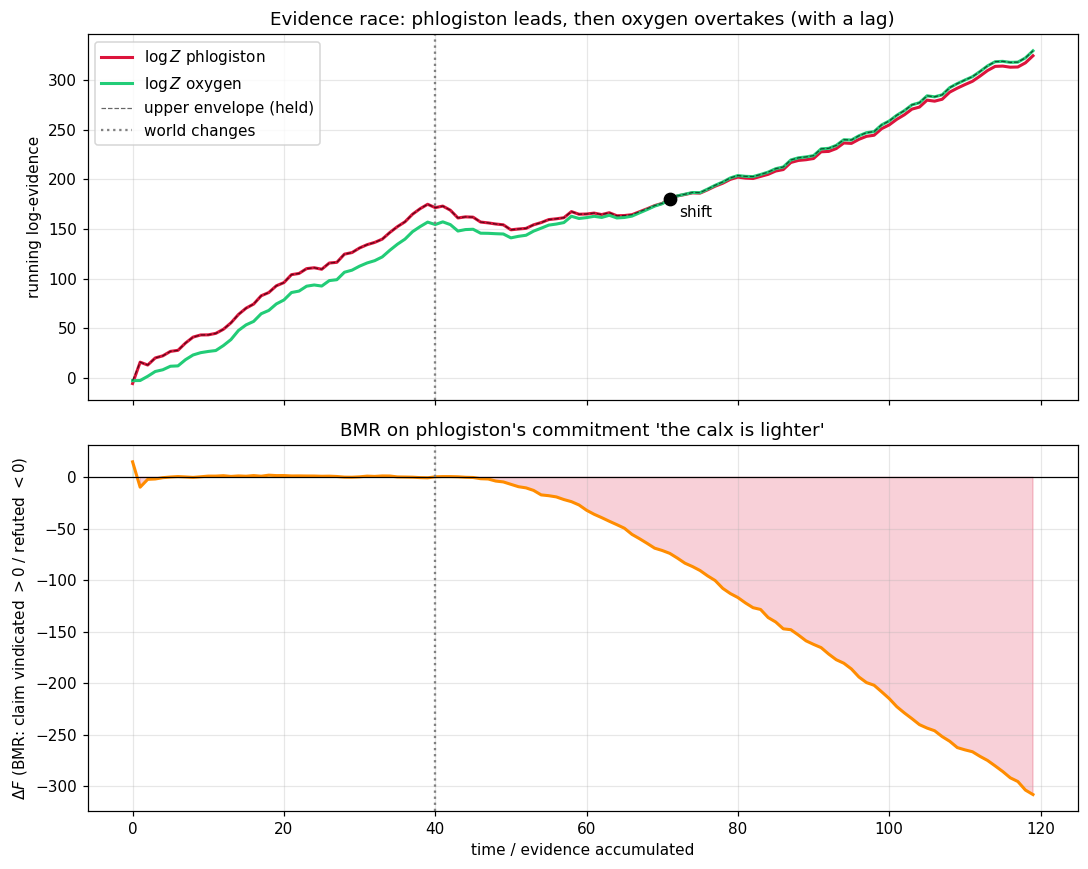

world changes at t=40; evidence envelope crosses at t=71 (lag 31)


In [5]:
race = st.evidence_race(cfg, jax.random.PRNGKey(0))
t = np.asarray(race['t'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax1.plot(t, np.asarray(race['logZ_phlog']), color='crimson', lw=2, label='$\\log Z$ phlogiston')
ax1.plot(t, np.asarray(race['logZ_oxy']), color='#2c7', lw=2, label='$\\log Z$ oxygen')
env = np.maximum(np.asarray(race['logZ_phlog']), np.asarray(race['logZ_oxy']))
ax1.plot(t, env, 'k--', lw=0.8, alpha=0.6, label='upper envelope (held)')
ax1.axvline(cfg.t_shift, color='grey', ls=':', label='world changes')
gap = np.asarray(race['gap']); cr = np.where(np.diff(np.sign(gap)) != 0)[0]
for c in cr:
    if c >= cfg.t_shift: ax1.plot(c, env[c], 'ko', ms=8); ax1.annotate('shift', (c, env[c]), textcoords='offset points', xytext=(6, -12))
ax1.set_ylabel('running log-evidence'); ax1.legend(loc='upper left'); ax1.set_title('Evidence race: phlogiston leads, then oxygen overtakes (with a lag)')

dF = np.asarray(race['delta_F'])
ax2.plot(t, dF, color='darkorange', lw=2)
ax2.axhline(0, color='k', lw=0.8); ax2.axvline(cfg.t_shift, color='grey', ls=':')
ax2.fill_between(t, 0, dF, where=(dF > 0), color='#2c7', alpha=0.2)
ax2.fill_between(t, 0, dF, where=(dF < 0), color='crimson', alpha=0.2)
ax2.set_ylabel('$\\Delta F$ (BMR: claim vindicated $>0$ / refuted $<0$)'); ax2.set_xlabel('time / evidence accumulated')
ax2.set_title("BMR on phlogiston's commitment 'the calx is lighter'")
plt.tight_layout(); plt.show()

shift_cross = cr[cr >= cfg.t_shift][0] if np.any(cr >= cfg.t_shift) else None
print(f'world changes at t={cfg.t_shift}; evidence envelope crosses at t={shift_cross} (lag {None if shift_cross is None else shift_cross-cfg.t_shift})')


## 4. Multi-agent full communication

Now $N$ agents on a small-world social graph (`src/network.build_adjacency`), each carrying a full
phlogiston net. Every round they transmit their **entire** $(\Pi, h)$ and fuse by trust-weighted
precision addition $\Pi_i \leftarrow \sum_j W_{ij}\Pi_j$ -- the matrix lift of the scalar
`precision_pool`. We compare the population order parameter $m(t)$ (mean oxygen index) **with** vs
**without** communication.


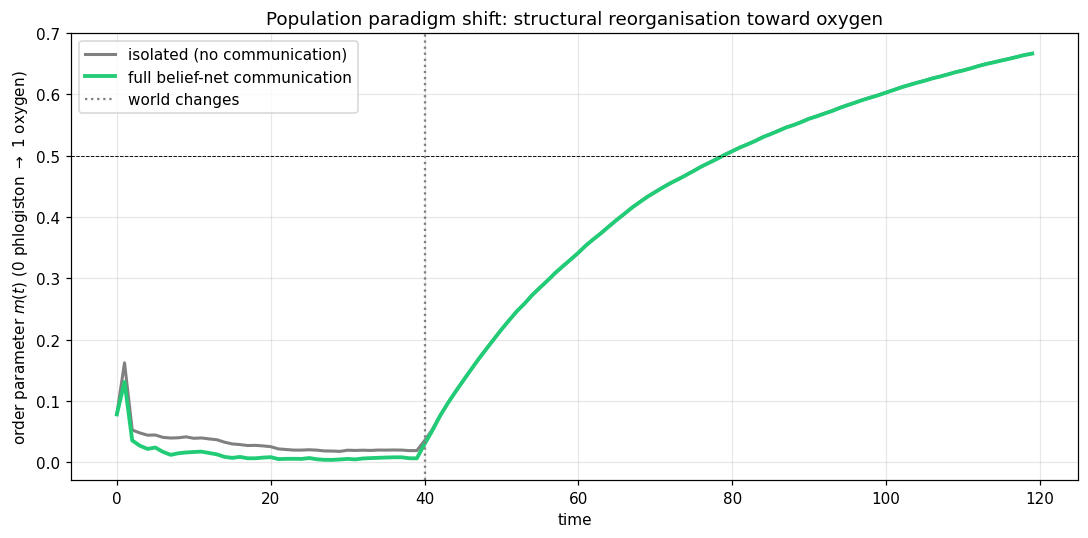

half-crossing: fused t=78, isolated t=78 (t_shift=40)


In [6]:
import dataclasses
cfg_m = ph.StructuralConfig(n_agents=60, n_steps=120, t_shift=40)
key = jax.random.PRNGKey(0)

def run_collect(state, cfg):
    h = History(); xs = []
    for tt in range(cfg.n_steps):
        state, out = S.step(state, cfg, tt); xs.append(out['order_parameter'])
    return np.asarray(xs)

# fused (full communication over the social graph)
state_f = S.init_state(cfg_m, key)
m_fused = run_collect(state_f, cfg_m)
# isolated baseline: replace W with identity (no communication)
state_i = S.init_state(cfg_m, key)
state_i = dataclasses.replace(state_i, W=jax.numpy.eye(cfg_m.n_agents))
m_iso = run_collect(state_i, cfg_m)

tt = np.arange(cfg_m.n_steps)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tt, m_iso, color='grey', lw=2, label='isolated (no communication)')
ax.plot(tt, m_fused, color='#2c7', lw=2.5, label='full belief-net communication')
ax.axhline(0.5, color='k', lw=0.6, ls='--'); ax.axvline(cfg_m.t_shift, color='grey', ls=':', label='world changes')
ax.set_xlabel('time'); ax.set_ylabel('order parameter $m(t)$ (0 phlogiston $\\to$ 1 oxygen)')
ax.set_title('Population paradigm shift: structural reorganisation toward oxygen'); ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

def cross_half(m):
    c = np.where(np.diff(np.sign(m - 0.5)) != 0)[0]
    return int(c[0]) if len(c) else None
print(f'half-crossing: fused t={cross_half(m_fused)}, isolated t={cross_half(m_iso)} (t_shift={cfg_m.t_shift})')


## 4b. Heterogeneous schools: different populations, different initial weightings

Section 4's honest null came from a *homogeneous* population. Here we break the symmetry the
way the structural model allows: agents have no utility function, so the analogue of a
"different initial utility weighting" is a **different prior** — its **stance** (the prior mean on
the disagreement / mass-law nodes, $\mu_{\text{phlog mass}}$) and its **confidence** (the prior
precision, scaling `base_prec` & `hub_self_prec`). We split $N=60$ into three stance$\times$confidence
**schools**: a *dogmatic phlogistonist* bloc (strong $-$stance, high precision), an *open agnostic*
bloc (neutral stance, low precision), and a *confident proto-oxygenist* bloc ($+$stance).

Crucially, only each school's **prior** is patched (via `init_state(..., groups=schools)`); the
world schedule `phi_true_at` and the order-parameter normalisation keep the canonical config, so
the truth and the metric are untouched. Because fusion is **precision-weighted**
($\Pi_i\leftarrow\sum_j W_{ij}\Pi_j$), heterogeneous beliefs are no longer fusion-invariant — the
social channel finally does work. The question is *what* work: changing **when** the population
shifts, or changing **how much the schools agree**.


In [1]:
# Heterogeneous population: three stance x confidence schools (counts sum to 60).
# stance  -> prior mean on the mass-law nodes (phlogiston-committed < 0 < oxygen-leaning)
# prec_scale -> prior confidence (scales base_prec & hub_self_prec): dogmatic vs open.
cfg_h = ph.StructuralConfig(n_agents=60, n_steps=120, t_shift=40)
schools = [
    dict(count=20, stance=-1.5, prec_scale=2.0, label='dogmatic phlogistonist',    color='crimson'),
    dict(count=20, stance= 0.0, prec_scale=0.5, label='open agnostic',             color='#888888'),
    dict(count=20, stance=+0.6, prec_scale=1.5, label='confident proto-oxygenist', color='#2c7'),
]
counts = [g['count'] for g in schools]
gid    = np.repeat(np.arange(len(schools)), counts)          # per-agent school id
key    = jax.random.PRNGKey(0)

def run_schools(state, cfg):
    """Roll out, recording the population order parameter and the per-school
    order parameter (obs.order_parameter works on any agent subset)."""
    mpop, mschool = [], []
    for tt in range(cfg.n_steps):
        state, out = S.step(state, cfg, tt)
        mpop.append(out['order_parameter'])
        row = [float(obs.order_parameter(
                   state.Pi[np.where(gid == g)[0]], state.h[np.where(gid == g)[0]],
                   cfg.node_names, ph.DISAGREEMENT_NODES, cfg.mu_phlog_mass, cfg.mu_oxy_mass))
               for g in range(len(schools))]
        mschool.append(row)
    return np.asarray(mpop), np.asarray(mschool)        # (T,), (T, n_schools)

# fused (full belief-net communication) vs isolated (W = identity)
mpop_f, msch_f = run_schools(S.init_state(cfg_h, key, groups=schools), cfg_h)
state_i = dataclasses.replace(S.init_state(cfg_h, key, groups=schools),
                              W=jax.numpy.eye(cfg_h.n_agents))
mpop_i, msch_i = run_schools(state_i, cfg_h)

tt = np.arange(cfg_h.n_steps)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

# (i) population order parameter: fused vs isolated
axL.plot(tt, mpop_i, color='grey', lw=2, label='isolated')
axL.plot(tt, mpop_f, color='#2c7', lw=2.5, label='full communication')
axL.axhline(0.5, color='k', lw=0.6, ls='--'); axL.axvline(cfg_h.t_shift, color='grey', ls=':')
axL.set_xlabel('time'); axL.set_ylabel('population $m(t)$')
axL.set_title('Population shift (world-driven timing)'); axL.legend(loc='upper left')

# (ii) per-school order parameter: fused (solid) converges; isolated (dashed) stays apart
for g, sc in enumerate(schools):
    axR.plot(tt, msch_f[:, g], color=sc['color'], lw=2.2, label=sc['label'])
    axR.plot(tt, msch_i[:, g], color=sc['color'], lw=1.4, ls='--', alpha=0.7)
axR.axhline(0.5, color='k', lw=0.6, ls='--'); axR.axvline(cfg_h.t_shift, color='grey', ls=':')
axR.set_xlabel('time'); axR.set_ylabel('per-school $m(t)$')
axR.set_title('Schools: fused (solid) reach consensus, isolated (dashed) do not')
axR.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

def cross_half(m):
    c = np.where(np.diff(np.sign(m - 0.5)) != 0)[0]
    return int(c[0]) if len(c) else None
spread = lambda row: float(row.max() - row.min())
print(f'population half-crossing:  fused t={cross_half(mpop_f)},  isolated t={cross_half(mpop_i)}'
      f'  (world changes at t={cfg_h.t_shift})')
print(f'inter-school spread @ t=0:    fused {spread(msch_f[0]):.3f},  isolated {spread(msch_i[0]):.3f}')
print(f'inter-school spread @ t=end:  fused {spread(msch_f[-1]):.3f},  isolated {spread(msch_i[-1]):.3f}')
print(f'max |fused - isolated| population gap: {np.abs(mpop_f - mpop_i).max():.3f}')
print('--> communication compresses inter-school disagreement (consensus) but does'
      ' NOT move the world-driven population crossing time.')


NameError: name 'ph' is not defined

## 5. Summary

- The **phlogiston hub's Schur fill-in is the Lavoisian mass law**: removing the hidden principle
  does not delete it, it re-precipitates as direct couplings among the surviving commitments.
- The **upper envelope of the candidate log-evidences is the held paradigm**; its crossing is the
  paradigm shift, and it **lags** the world-change -- phlogiston banks an evidence lead during its
  good regime that the new data take time to erode (paradigm inertia).
- **BMR localises falsification** to the specific vulnerable commitment (*calx lighter*): a modest
  Occam vindication while the regime holds, a catastrophic refutation once gravimetry reveals the
  mass gain.
- **Full belief-net communication** is a one-line precision addition that carries the
  precision-weighted mean for free. Honest finding: in this **homogeneous** population (identical
  priors, one shared world) the fused and isolated order parameters cross at the *same* time --
  fusing identically-distributed beliefs is essentially the identity on the mean trajectory. The
  social channel becomes consequential only with heterogeneity (divergent priors, private worlds,
  or trust asymmetry), which is the natural next experiment on this substrate.
